# Baseline Modeling: Unaided Brand Recall Binary Classification

## 1. Setup & Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Metrics & Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import StratifiedKFold, GroupShuffleSplit, cross_validate
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.base import clone
from sklearn.inspection import permutation_importance

from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

from xgboost import XGBClassifier

from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Utilities
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option("display.max_columns", 60)
pd.set_option("display.precision", 3)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (6, 3)

RANDOM_STATE = 22122025

## 2. Load Data

In [2]:
# Load train and val data
df = pd.read_parquet('../../data/final_for_modeling/train_ad_break_level_data.parquet')
segment_df = pd.read_parquet('../../data/final_for_modeling/segment_df.parquet')
print(f"Train shape: {df.shape}")
print(f"Segment shape: {segment_df.shape}")

Train shape: (1970, 22)
Segment shape: (2835, 50)


In [ ]:
full_df = df.merge(segment_df, on='ad_break_session_key', how='left')
full_df.head()

In [4]:
plt.figure(figsize=(14, 12))
sns.heatmap(full_df[full_df.dtypes[full_df.dtypes.isin(['float64', 'int64', 'Int64'])].index.sort_values()].corr().round(2), cmap='coolwarm')
full_df[full_df.dtypes[full_df.dtypes.isin(['float64', 'int64', 'Int64'])].index].corr().round(2)

,unaided_brand_recall,participant_id_calculated,start,duration,ad_index_in_break,is_first_ad_in_break,is_last_ad_in_break,is_repeated_exposure,experiment_sequence,ads_break_duration_s,total_ads_in_break,content_index,ad_quality_index,brand_influence,z-a_mean-psd_Delta_frontal-midline_v^2/Hz,z-a_mean-psd_Delta_prefrontal_v^2/Hz,z-a_mean-psd_Delta_anterior-frontal_v^2/Hz,z-a_mean-psd_Delta_frontolateral_v^2/Hz,z-a_mean-psd_Delta_frontolateral-ext_v^2/Hz,z-a_mean-psd_Delta_left-frontolateral-ext_v^2/Hz,z-a_mean-psd_Delta_right-frontolateral-ext_v^2/Hz,z-a_mean-psd_Theta_frontal-midline_v^2/Hz,z-a_mean-psd_Theta_prefrontal_v^2/Hz,z-a_mean-psd_Theta_anterior-frontal_v^2/Hz,z-a_mean-psd_Theta_frontolateral_v^2/Hz,z-a_mean-psd_Theta_frontolateral-ext_v^2/Hz,z-a_mean-psd_Theta_left-frontolateral-ext_v^2/Hz,z-a_mean-psd_Theta_right-frontolateral-ext_v^2/Hz,z-a_mean-psd_Alpha-upper_frontal-midline_v^2/Hz,z-a_mean-psd_Alpha-upper_prefrontal_v^2/Hz,...,z-a_mean-psd_Alpha-upper_left-frontolateral-ext_v^2/Hz,z-a_mean-psd_Alpha-upper_right-frontolateral-ext_v^2/Hz,z-a_mean-psd_Beta_frontal-midline_v^2/Hz,z-a_mean-psd_Beta_prefrontal_v^2/Hz,z-a_mean-psd_Beta_anterior-frontal_v^2/Hz,z-a_mean-psd_Beta_frontolateral_v^2/Hz,z-a_mean-psd_Beta_frontolateral-ext_v^2/Hz,z-a_mean-psd_Beta_left-frontolateral-ext_v^2/Hz,z-a_mean-psd_Beta_right-frontolateral-ext_v^2/Hz,z-a_mean-psd_Gamma_frontal-midline_v^2/Hz,z-a_mean-psd_Gamma_prefrontal_v^2/Hz,z-a_mean-psd_Gamma_anterior-frontal_v^2/Hz,z-a_mean-psd_Gamma_frontolateral_v^2/Hz,z-a_mean-psd_Gamma_frontolateral-ext_v^2/Hz,z-a_mean-psd_Gamma_left-frontolateral-ext_v^2/Hz,z-a_mean-psd_Gamma_right-frontolateral-ext_v^2/Hz,z-a_EI-2c_frontal-midline,z-a_AI-1a_frontal-midline,z-a_EI-2c_prefrontal,z-a_AI-1a_prefrontal,z-a_EI-2c_anterior-frontal,z-a_AI-1a_anterior-frontal,z-a_EI-2c_frontolateral,z-a_AI-1a_frontolateral,z-a_EI-2c_frontolateral-ext,z-a_AI-1a_frontolateral-ext,z-a_EI-2c_left-frontolateral-ext,z-a_AI-1a_left-frontolateral-ext,z-a_EI-2c_right-frontolateral-ext,z-a_AI-1a_right-frontolateral-ext
unaided_brand_recall,1.00,-0.02,-0.05,0.03,-0.07,0.04,-0.02,0.11,0.20,-0.05,-0.06,0.02,0.06,-0.05,0.04,0.04,0.04,-0.00,0.02,0.04,0.00,0.04,0.04,0.03,0.00,0.02,0.04,-0.00,0.02,0.02,...,0.01,-0.00,-0.02,-0.01,-0.02,-0.04,-0.03,-0.03,-0.02,-0.05,-0.05,-0.04,-0.05,-0.04,-0.04,-0.02,-0.05,0.04,-0.05,0.04,-0.05,0.03,-0.04,0.02,-0.05,0.03,-0.04,0.05,-0.03,0.00
participant_id_calculated,-0.02,1.00,0.00,0.01,-0.02,0.01,-0.01,0.02,-0.02,-0.01,-0.02,-0.13,-0.19,0.05,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.00,-0.01,0.00,-0.01,-0.01,-0.01,-0.00,-0.03,-0.03,...,-0.03,-0.02,-0.03,-0.02,-0.03,-0.03,-0.03,-0.02,-0.04,-0.02,-0.02,-0.02,-0.02,-0.03,-0.03,-0.03,0.01,0.01,0.01,0.01,0.01,0.02,0.02,0.01,0.01,0.01,0.03,0.00,-0.01,0.02
start,-0.05,0.00,1.00,-0.18,0.84,-0.52,0.31,-0.07,0.04,0.36,0.37,0.05,0.03,-0.02,0.07,0.07,0.06,0.06,0.06,0.06,0.05,0.04,0.04,0.03,0.05,0.05,0.03,0.05,0.06,0.06,...,0.07,0.06,0.08,0.08,0.07,0.12,0.10,0.08,0.11,0.01,0.00,0.02,0.03,0.03,0.03,0.02,-0.00,-0.01,-0.00,-0.01,-0.00,-0.01,0.01,-0.01,0.01,-0.00,-0.00,-0.01,0.01,-0.01
duration,0.03,0.01,-0.18,1.00,-0.17,0.14,0.22,0.16,-0.01,-0.18,-0.25,-0.00,0.01,0.03,-0.15,-0.13,-0.16,-0.12,-0.16,-0.16,-0.11,-0.16,-0.15,-0.16,-0.13,-0.16,-0.12,-0.16,-0.09,-0.08,...,-0.05,-0.10,-0.07,-0.08,-0.06,-0.06,-0.06,-0.05,-0.06,-0.02,-0.03,-0.01,-0.00,-0.01,-0.00,-0.00,0.08,-0.12,0.07,-0.11,0.07,-0.12,0.04,-0.08,0.07,-0.12,0.04,-0.09,0.07,-0.12
ad_index_in_break,-0.07,-0.02,0.84,-0.17,1.00,-0.58,0.36,-0.08,0.04,0.45,0.48,0.01,0.00,-0.05,0.06,0.06,0.05,0.05,0.05,0.05,0.04,0.03,0.04,0.02,0.04,0.04,0.03,0.04,0.07,0.07,...,0.07,0.07,0.09,0.09,0.08,0.14,0.11,0.10,0.12,0.02,0.02,0.04,0.03,0.03,0.04,0.02,0.00,-0.02,0.00,-0.01,0.01,-0.02,0.01,-0.01,0.01,-0.01,0.00,-0.01,0.02,-0.03
is_first_ad_in_break,0.04,0.01,-0.52,0.14,-0.58,1.00,-0.22,0.02,-0.02,-0.22,-0.24,-0.01,-0.00,0.02,-0.04,-0.04,-0.05,-0.06,-0.05,-0.06,-0.03,-0.04,-0.04,-0.03,-0.05,-0.04,-0.04,-0.04,-0.07,-0.07,...,-

## 3. Prepare Features and Target

splitting the data into train and dev sets based on 'participant_id_calculated' to prevent data leakage.

In [5]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.1,
        random_state=22122025)

train_idx, val_idx = next(
    gss.split(
        full_df.iloc[:, 3:],
        full_df['unaided_brand_recall'],
        groups=full_df['participant_id_calculated'])
)

print("Train idx:", train_idx.shape)
print("valiation idx:", val_idx.shape)

train_df = full_df.iloc[train_idx].reset_index(drop=True)
val_df = full_df.iloc[val_idx].reset_index(drop=True)

Train idx: (1803,)
valiation idx: (167,)


In [6]:
def custom_get_dummies(df, columns):
    """Custom one-hot encoding for categorical variables."""
    final_df = df.copy()
    final_df = pd.get_dummies(final_df, columns=columns)
    return final_df

dummy_columns = ['category', 'brand',  'content_watched', 
                'device', 'seen_ad_before_score', 'age_group', 'gender']

In [7]:
drop_cols = [
    'ad_break_session_key',
    'participant_id_calculated',
]

target_col = 'unaided_brand_recall'

train_df.drop(columns=drop_cols, inplace=True)
val_df.drop(columns=drop_cols, inplace=True)


# === Prepare feature matrices and target vectors === #
X_train = train_df.drop(columns=[target_col])
X_val = val_df.drop(columns=[target_col])

X_train_dummy = custom_get_dummies(X_train, dummy_columns).drop(columns='seen_ad_before_score_Unknown')
X_val_dummy = custom_get_dummies(X_val, dummy_columns).drop(columns='seen_ad_before_score_Unknown')

y_train = train_df[target_col]
y_val = val_df[target_col]

## 4. Helper Functions

In [ ]:
# === Helper Functions === #
def train_model_dictionary(models_dict, X_train=X_train_dummy, y_train=y_train, X_val=X_val_dummy, y_val=y_val):
    """
    Train multiple models and evaluate them.
    
    Parameters:
    -----------
    models_dict : dict
        Dictionary of model name and model instance pairs
    X_train, y_train : array-like
        Training data
    X_val, y_val : array-like
        val data
    
    Returns:
    --------
    results_list : list
        List of evaluation results for each model
    trained_models : dict
        Dictionary of trained models
    """
    results_list = []
    trained_models = {}
    
    for model_name, model in models_dict.items():
        print(f"Training and evaluating: {model_name}")
        
        # Train the model
        model.fit(X_train, y_train)
        trained_models[model_name] = model
        
            
        # Predictions
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        y_val_pred_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Calculate metrics
        val_accuracy = accuracy_score(y_val, y_val_pred)
        train_accuracy = accuracy_score(y_train, y_train_pred)
        
        val_precision = precision_score(y_val, y_val_pred)
        train_precision = precision_score(y_train, y_train_pred)
        
        val_recall = recall_score(y_val, y_val_pred)
        train_recall = recall_score(y_train, y_train_pred)      
        
        val_f1 = f1_score(y_val, y_val_pred)
        train_f1 = f1_score(y_train, y_train_pred)

        if y_val_pred_proba is not None:
            val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)
            val_avg_precision = average_precision_score(y_val, y_val_pred_proba)
        else:
            val_roc_auc = None
            val_avg_precision = None
            
        val_bal_acc = balanced_accuracy_score(y_val, y_val_pred)
        train_bal_acc = balanced_accuracy_score(y_train, y_train_pred)

        report_dict = {
            'Model': model_name,
            'Val Accuracy': val_accuracy,
            'Train Accuracy': train_accuracy,
            'Val Precision': val_precision,
            'Train Precision': train_precision,
            'Val Recall': val_recall,
            'Train Recall': train_recall,
            'Val F1': val_f1,
            'Train F1': train_f1,
            'Val ROC-AUC': val_roc_auc,
            'Val Avg Precision': val_avg_precision,
            'Val Balanced Accuracy': val_bal_acc,
            'Train Balanced Accuracy': train_bal_acc
        }
        # Store results
        results_list.append(report_dict)
        
        print(pd.DataFrame([report_dict]).to_string(index=False, justify='center'))
        print("-"*40)

    
    return pd.DataFrame(results_list), trained_models

def roc_auc_curve_all(trained_models, X_val, y_val):
    """
    Plot ROC curves for all models in one plot for comparison.
    """
    plt.figure(figsize=(10, 8))
    
    for model_name, model in trained_models.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_val)[:, 1]
            fpr, tpr, _ = roc_curve(y_val, y_proba)
            auc = roc_auc_score(y_val, y_proba)
            
            plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison - All Models', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
def precision_recall_curve_all(trained_models, X_val, y_val):
    """
    Plot Precision-Recall curves for all models in one plot for comparison.
    """
    plt.figure(figsize=(10, 8))
    
    for model_name, model in trained_models.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_val)[:, 1]
            precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
            avg_precision = average_precision_score(y_val, y_proba)
            
            plt.plot(recall_vals, precision_vals, linewidth=2, label=f'{model_name} (AP = {avg_precision:.3f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison - All Models', fontweight='bold')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def report_plot(results_df, trained_models, X_val, y_val):
    """Generate evaluation report and plots for all trained models."""
    
    
    # ====== part 1: plots ====== #
    # Create a figure with 1 row and 2 columns for side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Plot ROC curves using the existing function logic
    ax_roc = axes[0]
    for model_name, model in trained_models.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_val)[:, 1]
            fpr, tpr, _ = roc_curve(y_val, y_proba)
            auc = roc_auc_score(y_val, y_proba)
            
            ax_roc.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc:.3f})')

    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier', alpha=0.5)
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('ROC Curve Comparison - All Models', fontweight='bold')
    ax_roc.legend(loc='lower right')
    ax_roc.grid(alpha=0.3)

    # Plot Precision-Recall curves using the existing function logic
    ax_pr = axes[1]
    for model_name, model in trained_models.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_val)[:, 1]
            precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
            avg_precision = average_precision_score(y_val, y_proba)
            
            ax_pr.plot(recall_vals, precision_vals, linewidth=2, label=f'{model_name} (AP = {avg_precision:.3f})')

    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title('Precision-Recall Curve Comparison - All Models', fontweight='bold')
    ax_pr.legend(loc='lower left')
    ax_pr.grid(alpha=0.3)

    plt.suptitle('Model Performance Curves Comparison', fontweight='bold', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ==== part 2: print report ==== #
    # Use the existing results_df to extract metrics data
    metrics_data = []
    for _, row in results_df.iterrows():
        metrics_data.append({
            'Model': row['Model'],
            'Val Precision': row['Val Precision'],
            'Train Precision': row['Train Precision'],
            'Val Recall': row['Val Recall'],
            'Train Recall': row['Train Recall'],
            'Val F1-Score': row['Val F1'],
            'Train F1-Score': row['Train F1'],
            'Val ROC-AUC': row['Val ROC-AUC'],
            'Val Accuracy': row['Val Accuracy'],
            'Train Accuracy': row['Train Accuracy'],
            'Val Avg Precision': row['Val Avg Precision'],
        })

    metrics_df = pd.DataFrame(metrics_data)

    # Create 2x2 subplot for metrics comparison
    fig, axes = plt.subplots(3, 2, figsize=(20, 12))

    # Plot Precision (Train vs Val)
    axes[0, 0].plot(metrics_df['Model'], metrics_df['Train Precision'], marker='o', linewidth=2, label='Train', color='blue', alpha=0.7)
    axes[0, 0].plot(metrics_df['Model'], metrics_df['Val Precision'], marker='s', linewidth=2, label='Val', color='blue', linestyle='--', alpha=0.7)
    axes[0, 0].set_title('Precision Comparison', fontweight='bold')
    axes[0, 0].set_ylabel('Precision')
    axes[0, 0].set_xticklabels([])
    axes[0, 0].grid(alpha=0.3)

    # Plot Recall (Train vs Val)
    axes[0, 1].plot(metrics_df['Model'], metrics_df['Train Recall'], marker='o', linewidth=2, label='Train', color='orange', alpha=0.7)
    axes[0, 1].plot(metrics_df['Model'], metrics_df['Val Recall'], marker='s', linewidth=2, label='Val', color='orange', linestyle='--', alpha=0.7)
    axes[0, 1].set_title('Recall Comparison', fontweight='bold')
    axes[0, 1].set_ylabel('Recall')
    axes[0, 1].set_xticklabels([])
    axes[0, 1].grid(alpha=0.3)

    # Plot F1-Score (Train vs Val)
    axes[1, 0].plot(metrics_df['Model'], metrics_df['Train F1-Score'], marker='o', linewidth=2, label='Train', color='green', alpha=0.7)
    axes[1, 0].plot(metrics_df['Model'], metrics_df['Val F1-Score'], marker='s', linewidth=2, label='Val', color='green', linestyle='--', alpha=0.7)
    axes[1, 0].set_title('F1-Score Comparison', fontweight='bold')
    axes[1, 0].set_ylabel('F1-Score')
    axes[1, 0].set_xticklabels([])
    axes[1, 0].grid(alpha=0.3)
    
    # plot Accuracy (Train vs Val)
    axes[1, 1].plot(metrics_df['Model'], metrics_df['Train Accuracy'], marker='o', linewidth=2, label='Train', color='purple', alpha=0.7)
    axes[1, 1].plot(metrics_df['Model'], metrics_df['Val Accuracy'], marker='s', linewidth=2, label='Val', color='purple', linestyle='--', alpha=0.7)
    axes[1, 1].set_title('Accuracy Comparison', fontweight='bold')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_xticklabels([])
    axes[1, 1].grid(alpha=0.3)
    
    # Plot ROC-AUC (Val only)
    axes[2, 0].plot(metrics_df['Model'], metrics_df['Val ROC-AUC'], marker='o', linewidth=2, color='red', label='Val')
    axes[2, 0].set_title('ROC-AUC Comparison', fontweight='bold')
    axes[2, 0].set_ylabel('ROC-AUC')
    axes[2, 0].tick_params(axis='x', rotation=90)
    axes[2, 0].grid(alpha=0.3)
    
    # plot Average Precision (Val only)
    axes[2, 1].plot(metrics_df['Model'], metrics_df['Val Avg Precision'], marker='o', linewidth=2, color='brown', label='Val')
    axes[2, 1].set_title('Average Precision Comparison', fontweight='bold')
    axes[2, 1].set_ylabel('Average Precision')
    axes[2, 1].tick_params(axis='x', rotation=90)
    axes[2, 1].grid(alpha=0.3)
    
    plt.suptitle('Model Performance Metrics Comparison (Train: line, Val: dashed)', fontweight='bold',  fontsize=12,)
    plt.tight_layout()
    plt.show()


## 5. Baseline Models





### 5.1 Define Models

In [9]:
LogRegModels = {
    # ==== Base Logistic Regression ==== #
    "LogReg_L2": LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "LogReg_L2_Balanced": LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    # ==== Stronger Regularization ==== #
    "LogReg_L2_C0.1": LogisticRegression(
        penalty="l2",
        C=0.1,
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "LogReg_L2_C0.1_Balanced": LogisticRegression(
        penalty="l2",
        C=0.1,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    # ==== L1 (Feature Selection) ==== #
    "LogReg_L1": LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "LogReg_L1_Balanced": LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    # ==== ElasticNet ==== #
    "LogReg_ElasticNet_50_50": LogisticRegression(
        penalty="elasticnet",
        C=0.5,
        l1_ratio=0.5,
        solver="saga",
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "LogReg_ElasticNet_50_50_Balanced": LogisticRegression(
        penalty="elasticnet",
        C=0.5,
        l1_ratio=0.5,
        solver="saga",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
}

models_dict = {
    # ==== Logistic Regression Models ==== #
    # 'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    # 'Logistic Regression (Balanced)': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'),
    
    # ==== L1 (Feature Selection) ==== # ==> out of above
    "LogReg_L1": LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "LogReg_L1_Balanced": LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    
    # ==== Tree-Based Models ==== #
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'RandomForest (balanced)': RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'Balanced Random Forest': BalancedRandomForestClassifier(random_state=RANDOM_STATE),
    'Easy Ensemble': EasyEnsembleClassifier(random_state=RANDOM_STATE),


    # ==== Boosting Models ==== #
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),    
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE),    
    
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    'LightGBM (balanced)': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, is_unbalance=True, class_weight='balanced'),

    'CatBoost': CatBoostClassifier(random_state=RANDOM_STATE, verbose=False),
    'CatBoost (balanced)': CatBoostClassifier(random_state=RANDOM_STATE, auto_class_weights='Balanced', verbose=False),

    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),

    # ==== SVM Models ==== #
    'SVM': SVC(random_state=RANDOM_STATE, probability=True, kernel='linear'),
    'SVM (RBF)': SVC(random_state=RANDOM_STATE, probability=True, kernel='rbf'),
    'SVM (RBF, balanced)': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),

    # ==== Other Models ==== #
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    
    # === Neural Network Models ==== #    
    'Neural Network (MLP)': MLPClassifier(random_state=RANDOM_STATE, max_iter=1000)
}

Train Log regression models with and without class balancing.

### 5.2 Train and Evaluate Models

- Overall Evaluation Criteria: ROC-AUC, PR-AUC, F1-Score, Accuracy

#### 5.2.1 Logistic Regression Results

In [10]:
logreg_results, logreg_trained_models = train_model_dictionary(LogRegModels)

Training and evaluating: LogReg_L2
  Model    Val Accuracy  Train Accuracy  Val Precision  Train Precision  Val Recall  Train Recall  Val F1  Train F1  Val ROC-AUC  Val Avg Precision  Val Balanced Accuracy  Train Balanced Accuracy
LogReg_L2     0.796           0.87          0.854           0.868          0.868        0.955      0.861     0.91       0.84           0.925                0.738                   0.821          
----------------------------------------
Training and evaluating: LogReg_L2_Balanced
      Model         Val Accuracy  Train Accuracy  Val Precision  Train Precision  Val Recall  Train Recall  Val F1  Train F1  Val ROC-AUC  Val Avg Precision  Val Balanced Accuracy  Train Balanced Accuracy
LogReg_L2_Balanced     0.766          0.855          0.902           0.917           0.76        0.865      0.825    0.891       0.84           0.925                0.771                   0.848          
----------------------------------------
Training and evaluating: LogReg_L2_C0

In [11]:
report_plot(logreg_results, logreg_trained_models, X_val_dummy, y_val)
print(logreg_results.to_string(index=False, justify='center'))

             Model                Val Accuracy  Train Accuracy  Val Precision  Train Precision  Val Recall  Train Recall  Val F1  Train F1  Val ROC-AUC  Val Avg Precision  Val Balanced Accuracy  Train Balanced Accuracy
                       LogReg_L2     0.796          0.870          0.854           0.868          0.868        0.955      0.861    0.910      0.840           0.925                0.738                   0.821          
              LogReg_L2_Balanced     0.766          0.855          0.902           0.917          0.760        0.865      0.825    0.891      0.840           0.925                0.771                   0.848          
                  LogReg_L2_C0.1     0.778          0.846          0.828           0.836          0.876        0.964      0.851    0.896      0.811           0.910                0.699                   0.778          
         LogReg_L2_C0.1_Balanced     0.766          0.830          0.910           0.907          0.752        0.837      0.

> The best on is LogReg-L1 has the highest ROC-AUC and Val F1 score on validation set .

##### **deeper analysis of LogReg-L1**

In [12]:
selected_model = logreg_trained_models['LogReg_L1']

# Feature Importance using Coefficients
feature_importance_temp = pd.DataFrame({
    'Feature': X_train_dummy.columns,
    'Coefficient': selected_model.coef_[0],
    'Odd Ratio': np.exp(selected_model.coef_[0])
})
feature_importance_temp['Abs_Coefficient'] = feature_importance_temp['Coefficient'].abs()
print(feature_importance_temp.to_string())

                                                     Feature  Coefficient  Odd Ratio  Abs_Coefficient
0                                                      start        0.000      1.000            0.000
1                                                   duration        0.000      1.000            0.000
2                                          ad_index_in_break       -0.106      0.900            0.106
3                                       is_first_ad_in_break        0.000      1.000            0.000
4                                        is_last_ad_in_break        0.087      1.091            0.087
5                                       is_repeated_exposure        0.923      2.517            0.923
6                                        experiment_sequence        0.555      1.742            0.555
7                                       ads_break_duration_s       -0.105      0.900            0.105
8                                         total_ads_in_break       -0.125      0.8

In [ ]:
for col in dummy_columns:
    feat_imp_cat = feature_importance_temp[feature_importance_temp['Feature'].str.startswith(col)]
    
    if len(feat_imp_cat) > 0:  # Only plot if there are features for this category #####
        plt.figure(figsize=(6, max(3, len(feat_imp_cat) * 0.3)))
        plt.barh(feat_imp_cat['Feature'], feat_imp_cat['Coefficient'])
        plt.xlabel('Coefficient')
        plt.title(f'Feature Importance for {col}')

        plt.show()

< RemovedDueToNDA >

< RemovedDueToNDA >

< RemovedDueToNDA >

< RemovedDueToNDA >

< RemovedDueToNDA >

In [14]:
feature_importance_temp.sort_values(by='Abs_Coefficient', ascending=False).head(25).round(3)

,Feature,Coefficient,Odd Ratio,Abs_Coefficient
131,seen_ad_before_score_0.0,5.116,166.677,5.116
134,seen_ad_before_score_1.0,4.899,134.132,4.899
133,seen_ad_before_score_0.5,4.748,115.320,4.748
132,seen_ad_before_score_0.33,4.641,103.669,4.641
78,brand_< RemovedDueToNDA >,-2.051,0.129,2.051
82,brand_< RemovedDueToNDA >,-1.547,0.213,1.547
79,brand_< RemovedDueToNDA >,-1.467,0.231,1.467
61,category_alim,-1.448,0.235,1.448
65,category_cosm,1.398,4.047,1.398
73,brand_< RemovedDueToNDA >,1.310,3.707,1.310


### 5.2.2 Different Models Training and Evaluation Code

In [15]:
all_results, all_trained_models = train_model_dictionary(models_dict)

Training and evaluating: LogReg_L1
  Model    Val Accuracy  Train Accuracy  Val Precision  Train Precision  Val Recall  Train Recall  Val F1  Train F1  Val ROC-AUC  Val Avg Precision  Val Balanced Accuracy  Train Balanced Accuracy
LogReg_L1     0.814          0.867          0.857           0.867          0.893        0.953      0.874    0.908      0.848           0.929                0.751                   0.818          
----------------------------------------
Training and evaluating: LogReg_L1_Balanced
      Model         Val Accuracy  Train Accuracy  Val Precision  Train Precision  Val Recall  Train Recall  Val F1  Train F1  Val ROC-AUC  Val Avg Precision  Val Balanced Accuracy  Train Balanced Accuracy
LogReg_L1_Balanced     0.766          0.857           0.91           0.918          0.752        0.869      0.824    0.892      0.849           0.928                0.778                    0.85          
----------------------------------------
Training and evaluating: Decision Tre

In [16]:
report_plot(all_results, all_trained_models, X_val_dummy, y_val)
print(all_results.to_string(index=False, justify='center'))  

         Model           Val Accuracy  Train Accuracy  Val Precision  Train Precision  Val Recall  Train Recall  Val F1  Train F1  Val ROC-AUC  Val Avg Precision  Val Balanced Accuracy  Train Balanced Accuracy
              LogReg_L1     0.814          0.867          0.857           0.867          0.893        0.953      0.874    0.908      0.848           0.929                0.751                   0.818          
     LogReg_L1_Balanced     0.766          0.857          0.910           0.918          0.752        0.869      0.824    0.892      0.849           0.928                0.778                   0.850          
          Decision Tree     0.784          1.000          0.897           1.000          0.793        1.000      0.842    1.000      0.777           0.862                0.777                   1.000          
          Random Forest     0.766          1.000          0.773           1.000          0.959        1.000      0.856    1.000      0.752           0.882      

In [17]:
shortlisted_results = (
    all_results.round(3).sort_values(by='Val ROC-AUC', ascending=False).iloc[:5,:] # top 5 roc
        ).sort_values(by='Val F1', ascending=False)

report_plot(shortlisted_results, 
            {name: all_trained_models[name] for name in shortlisted_results['Model']}, 
            X_val_dummy, y_val)
print(shortlisted_results.to_string(index=False, justify='center'))

      Model         Val Accuracy  Train Accuracy  Val Precision  Train Precision  Val Recall  Train Recall  Val F1  Train F1  Val ROC-AUC  Val Avg Precision  Val Balanced Accuracy  Train Balanced Accuracy
 Gradient Boosting     0.856          0.916          0.876           0.907          0.934        0.978      0.904    0.941      0.856           0.928                0.793                   0.880          
               SVM     0.850          0.866          0.864           0.855          0.942        0.968      0.901    0.908      0.854           0.930                0.775                   0.807          
          CatBoost     0.814          0.981          0.836           0.977          0.926        0.995      0.878    0.986      0.849           0.926                0.724                   0.972          
         LogReg_L1     0.814          0.867          0.857           0.867          0.893        0.953      0.874    0.908      0.848           0.929                0.751          

### 5.3 Best Model Details and Evaluation

we have to decide between `Gradient Boosting` and `SVM`. 
    They have very close performance on validation set, but **Gradient Boosting** is slightly better in terms of ROC-AUC and F1-score. However **SVM** has lower overfitting (smaller gap between train and val scores) and higher PR-AUC on validation set.

In [18]:
top_models = {
    "Gradient Boosting": models_dict["Gradient Boosting"],
    "SVM": models_dict["SVM"]
}

## 6. CV for top models

In [20]:
from sklearn.model_selection import GroupKFold

N_SPLITS = 10
gkf = GroupKFold(n_splits=N_SPLITS)

# X
X = (
    custom_get_dummies(
        full_df.drop(columns=drop_cols + [target_col]),
        dummy_columns
    )
    .drop(columns='seen_ad_before_score_Unknown')
)

# y
y = full_df[target_col]

# groups
groups = full_df['participant_id_calculated']

cv_results = []

for name, model in top_models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=gkf,
        groups=groups,
        scoring={
            'auc': 'roc_auc',
            'f1': 'f1',
            'precision': 'precision',
            'recall': 'recall'
        },
        n_jobs=-1
    )

    cv_results.append({
        'Model': name,

        'Mean AUC': scores['test_auc'].mean(),
        'Std AUC': scores['test_auc'].std(),
        'Min AUC': scores['test_auc'].min(),
        'Max AUC': scores['test_auc'].max(),
        '|' : '|',

        'Mean F1': scores['test_f1'].mean(),
        'Std F1': scores['test_f1'].std(),
        'Min F1': scores['test_f1'].min(),
        'Max F1': scores['test_f1'].max(),
        '||' : '|',

        'Mean Precision': scores['test_precision'].mean(),
        'Std Precision': scores['test_precision'].std(),
        'Min Precision': scores['test_precision'].min(),
        'Max Precision': scores['test_precision'].max(),
        '|||' : '|',

        'Mean Recall': scores['test_recall'].mean(),
        'Std Recall': scores['test_recall'].std(),
        'Min Recall': scores['test_recall'].min(),
        'Max Recall': scores['test_recall'].max(),
    })

    print(
        f"{name:<25} "
        f"AUC: {scores['test_auc'].mean():.4f} "
        f"(± {scores['test_auc'].std():.4f})"
    )

cv_df = (
    pd.DataFrame(cv_results)
    .sort_values('Mean AUC', ascending=False)
    .reset_index(drop=True)
)


Gradient Boosting         AUC: 0.8803 (± 0.0218)
SVM                       AUC: 0.8760 (± 0.0263)


In [21]:
print("GROUPED CROSS-VALIDATION SUMMARY")
print("=" * 80)

print(cv_df.round(3).to_string(index=False, justify='center'))

GROUPED CROSS-VALIDATION SUMMARY
      Model        Mean AUC  Std AUC  Min AUC  Max AUC |  Mean F1  Std F1  Min F1  Max F1 ||  Mean Precision  Std Precision  Min Precision  Max Precision |||  Mean Recall  Std Recall  Min Recall  Max Recall
Gradient Boosting   0.880    0.022    0.841    0.913   |  0.894    0.013   0.870   0.912  |       0.848          0.025          0.801          0.894       |     0.947        0.022       0.914       0.984   
              SVM   0.876    0.026    0.829    0.914   |  0.889    0.018   0.858   0.915  |       0.845          0.026          0.805          0.882       |     0.939        0.032       0.871       0.976   


confidence interval for all scores:
Gradient Boosting         AUC        95% CI: (0.867, 0.894), Mean: 0.880, Std: 0.022
Gradient Boosting         F1         95% CI: (0.887, 0.902), Mean: 0.894, Std: 0.013
Gradient Boosting         Precision  95% CI: (0.833, 0.864), Mean: 0.848, Std: 0.025
Gradient Boosting         Recall     95% CI: (0.933, 0.960), Mean: 0.947, Std: 0.022
------------------------------------------------------------
SVM                       AUC        95% CI: (0.860, 0.892), Mean: 0.876, Std: 0.026
SVM                       F1         95% CI: (0.878, 0.900), Mean: 0.889, Std: 0.018
SVM                       Precision  95% CI: (0.829, 0.861), Mean: 0.845, Std: 0.026
SVM                       Recall     95% CI: (0.919, 0.959), Mean: 0.939, Std: 0.032
------------------------------------------------------------


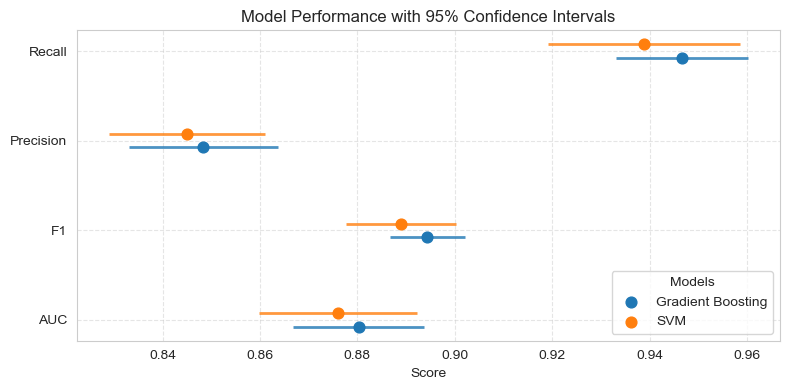

In [22]:
print("confidence interval for all scores:")
for _, row in cv_df.iterrows():
    for metric in ['AUC', 'F1', 'Precision', 'Recall']:
        mean = row[f'Mean {metric}']
        std = row[f'Std {metric}']
        ci_lower = mean - 1.96 * (std / np.sqrt(N_SPLITS))
        ci_upper = mean + 1.96 * (std / np.sqrt(N_SPLITS))
        print(f"{row['Model']:<25} {metric:<10} 95% CI: ({ci_lower:.3f}, {ci_upper:.3f}), Mean: {mean:.3f}, Std: {std:.3f}")
    print("-" * 60)
    
# plot the metrics of cross-validation
metrics = ['AUC', 'F1', 'Precision', 'Recall']
models = cv_df['Model'].unique()

y_base = np.arange(len(metrics))
offset = 0.15  # vertical separation between models

fig, ax = plt.subplots(figsize=(8, 4))

for i, model in enumerate(models):
    row = cv_df[cv_df['Model'] == model].iloc[0]

    means = np.array([row[f'Mean {m}'] for m in metrics])
    stds = np.array([row[f'Std {m}'] for m in metrics])
    ci = 1.96 * stds / np.sqrt(N_SPLITS)

    y_pos = y_base + (i - (len(models)-1)/2) * offset

    # confidence interval line
    ax.hlines(
        y=y_pos,
        xmin=means - ci,
        xmax=means + ci,
        linewidth=2,
        alpha=0.8,
        label=None,
        color=f"C{i}"
    )

    # mean point
    ax.scatter(
        means,
        y_pos,
        s=60,
        zorder=3,
        label=model
    )

# formatting
ax.set_yticks(y_base)
ax.set_yticklabels(metrics)
ax.set_xlabel("Score")
ax.set_title("Model Performance with 95% Confidence Intervals")

ax.grid(linestyle='--', alpha=0.5)
ax.legend(loc='lower right', title='Models')

plt.tight_layout()
plt.show()


the best model then, is `Gradient Boosting Classifier` with default hyperparameters.

In [23]:
benchmark_model = models_dict['Gradient Boosting']

## 7. Save the best model

In [24]:
path = '../../models/baseline_models/benchmark_model.pkl'
os.makedirs(os.path.dirname(path), exist_ok=True)
joblib.dump(benchmark_model, path)

['../../models/baseline_models/benchmark_model.pkl']